# 🌱 ArgoMind — Data Processing Notebook

Notebook ini melakukan **pemrosesan data** penuh dari file `Smart_Farming_Crop_Yield_2024.csv` untuk menghasilkan dataset siap latih bagi model prediksi penyakit tanaman.

## Alur Kerja

```
1. Load & Inspect        → Muat CSV, lihat bentuk, tipe data, dan sampel
2. Exploratory Analysis  → Distribusi, korelasi, dan visualisasi kunci
3. Data Cleaning         → Tangani missing values dan duplikat
4. Feature Engineering   → Buat fitur baru, encode kategoris
5. Feature Selection     → Pilih kolom yang relevan untuk model ArgoMind
6. Normalisasi           → StandardScaler pada fitur numerik
7. Train/Test Split      → 80/20 stratified split
8. Export               → Simpan dataset bersih ke CSV + scaler ke .pkl
```

---
## 0. Install & Import

In [1]:
# Install dependensi jika belum ada
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# Path relatif dari lokasi notebook ini
DATA_DIR  = Path('.')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RAW_CSV        = DATA_DIR / 'Smart_Farming_Crop_Yield_2024.csv'
CLEAN_CSV      = DATA_DIR / 'sensor_dataset_clean.csv'
TRAIN_CSV      = DATA_DIR / 'sensor_dataset_train.csv'
TEST_CSV       = DATA_DIR / 'sensor_dataset_test.csv'
SCALER_PATH    = MODEL_DIR / 'scaler.pkl'
ENCODER_PATH   = MODEL_DIR / 'label_encoder.pkl'

print('✅ Import selesai')

✅ Import selesai


---
## 1. Load & Inspect Data

In [3]:
df = pd.read_csv(RAW_CSV)
print(f'Shape  : {df.shape[0]:,} baris × {df.shape[1]} kolom')
df.head(5)

Shape  : 500 baris × 22 kolom


,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe


In [4]:
# Informasi tipe data dan jumlah non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    object 
 1   region                500 non-null    object 
 2   crop_type             500 non-null    object 
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    object 
 10  fertilizer_type       500 non-null    object 
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    object 
 13  harvest_date          500 non-null    object 
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  5

In [5]:
# Statistik deskriptif fitur numerik
df.describe().round(2)

,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,yield_kg_per_hectare,latitude,longitude,NDVI_index
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,26.75,6.52,24.68,181.69,65.19,7.03,26.59,119.50,4032.93,22.44,80.39,0.60
std,10.15,0.59,5.35,72.29,14.64,1.69,13.20,16.80,1174.43,7.28,5.91,0.18
min,10.16,5.51,15.00,50.17,40.23,4.01,5.05,90.00,2023.56,10.00,70.02,0.30
25%,17.89,6.03,20.30,119.22,51.86,5.67,14.94,105.75,2994.82,16.26,75.37,0.45
50%,25.86,6.53,24.66,191.54,65.68,7.00,25.98,119.00,4071.69,21.98,80.65,0.61
75%,36.02,7.04,29.09,239.04,77.99,8.47,38.01,134.00,5062.11,28.53,85.65,0.75
max,44.98,7.50,34.84,298.96,90.00,10.00,49.94,150.00,5998.29,34.98,89.99,0.90


In [6]:
# Distribusi label target: crop_disease_status
print('Distribusi Label Target:')
print(df['crop_disease_status'].value_counts())
print()
print('Distribusi (%) :')
print(df['crop_disease_status'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

Distribusi Label Target:
crop_disease_status
Severe      133
Mild        125
Moderate    112
Name: count, dtype: int64

Distribusi (%) :
crop_disease_status
Severe      35.95 %
Mild        33.78 %
Moderate    30.27 %
Name: proportion, dtype: object


---
## 2. Exploratory Data Analysis (EDA)

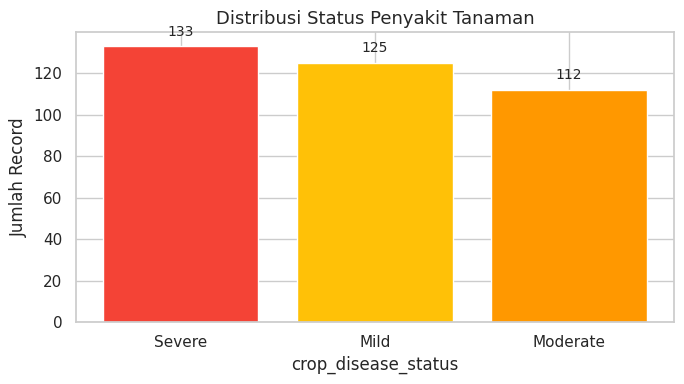

In [7]:
# ── 2.1 Distribusi label
# FIX: gunakan list-comprehension agar tipe menjadi list[str]/list[int] yang eksplisit
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['crop_disease_status'].value_counts()
color_map: dict[str, str] = {'None': '#4CAF50', 'Mild': '#FFC107', 'Moderate': '#FF9800', 'Severe': '#F44336'}
x_labels: list[str] = [str(x) for x in counts.index]
y_values: list[int] = [int(v) for v in counts.values]
bar_colors: list[str] = [color_map.get(str(x), '#90A4AE') for x in x_labels]
bars = ax.bar(x_labels, y_values, color=bar_colors)
for bar, val in zip(bars, y_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', fontsize=10)
ax.set_title('Distribusi Status Penyakit Tanaman', fontsize=13)
ax.set_xlabel('crop_disease_status')
ax.set_ylabel('Jumlah Record')
plt.tight_layout()
plt.show()

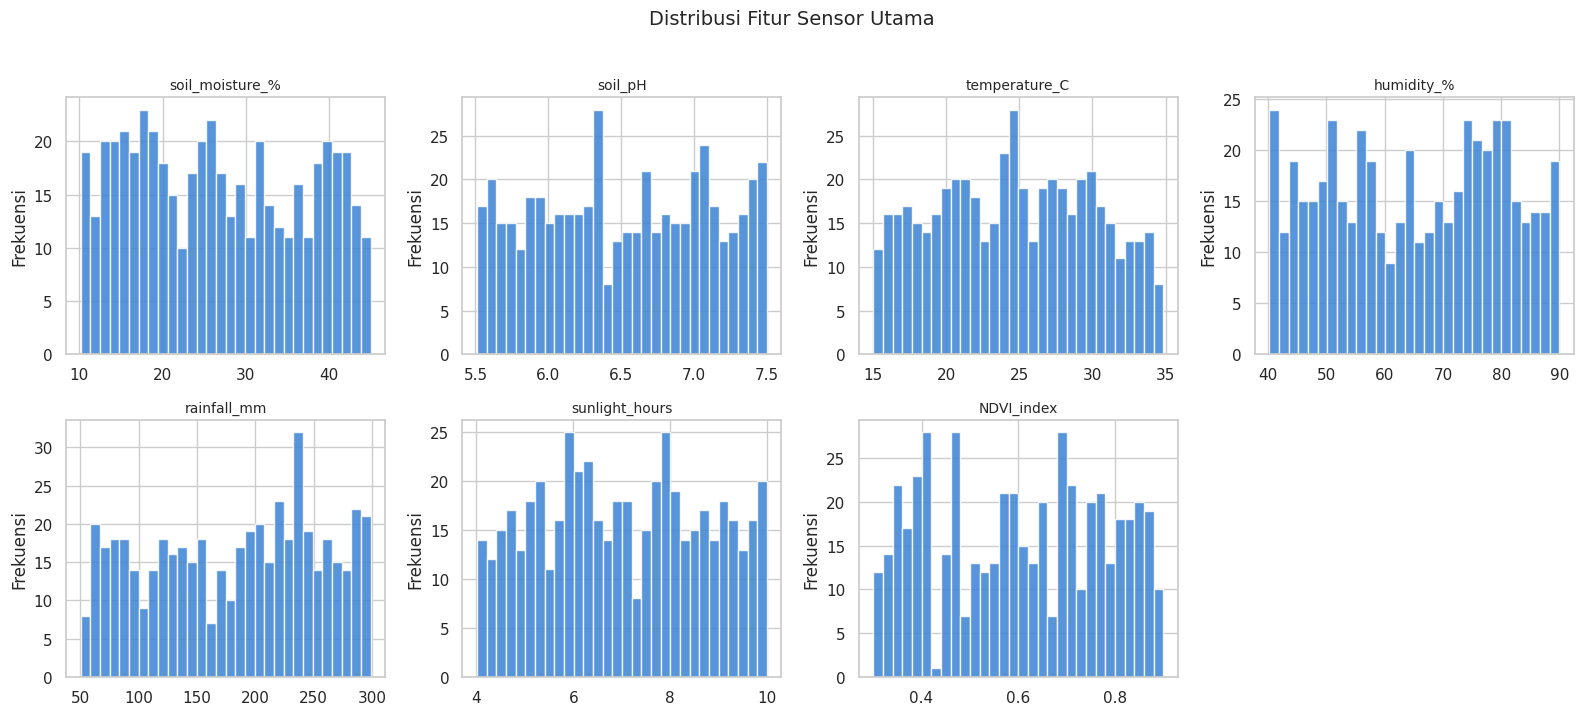

In [8]:
# ── 2.2 Histogram fitur sensor utama
sensor_cols: list[str] = ['soil_moisture_%', 'soil_pH', 'temperature_C', 'humidity_%',
                           'rainfall_mm', 'sunlight_hours', 'NDVI_index']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes_flat = axes.flatten()
for i, col in enumerate(sensor_cols):
    axes_flat[i].hist(df[col].dropna().tolist(), bins=30,
                      color='#3b82d4', edgecolor='white', alpha=0.85)
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_ylabel('Frekuensi')
axes_flat[-1].set_visible(False)
fig.suptitle('Distribusi Fitur Sensor Utama', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

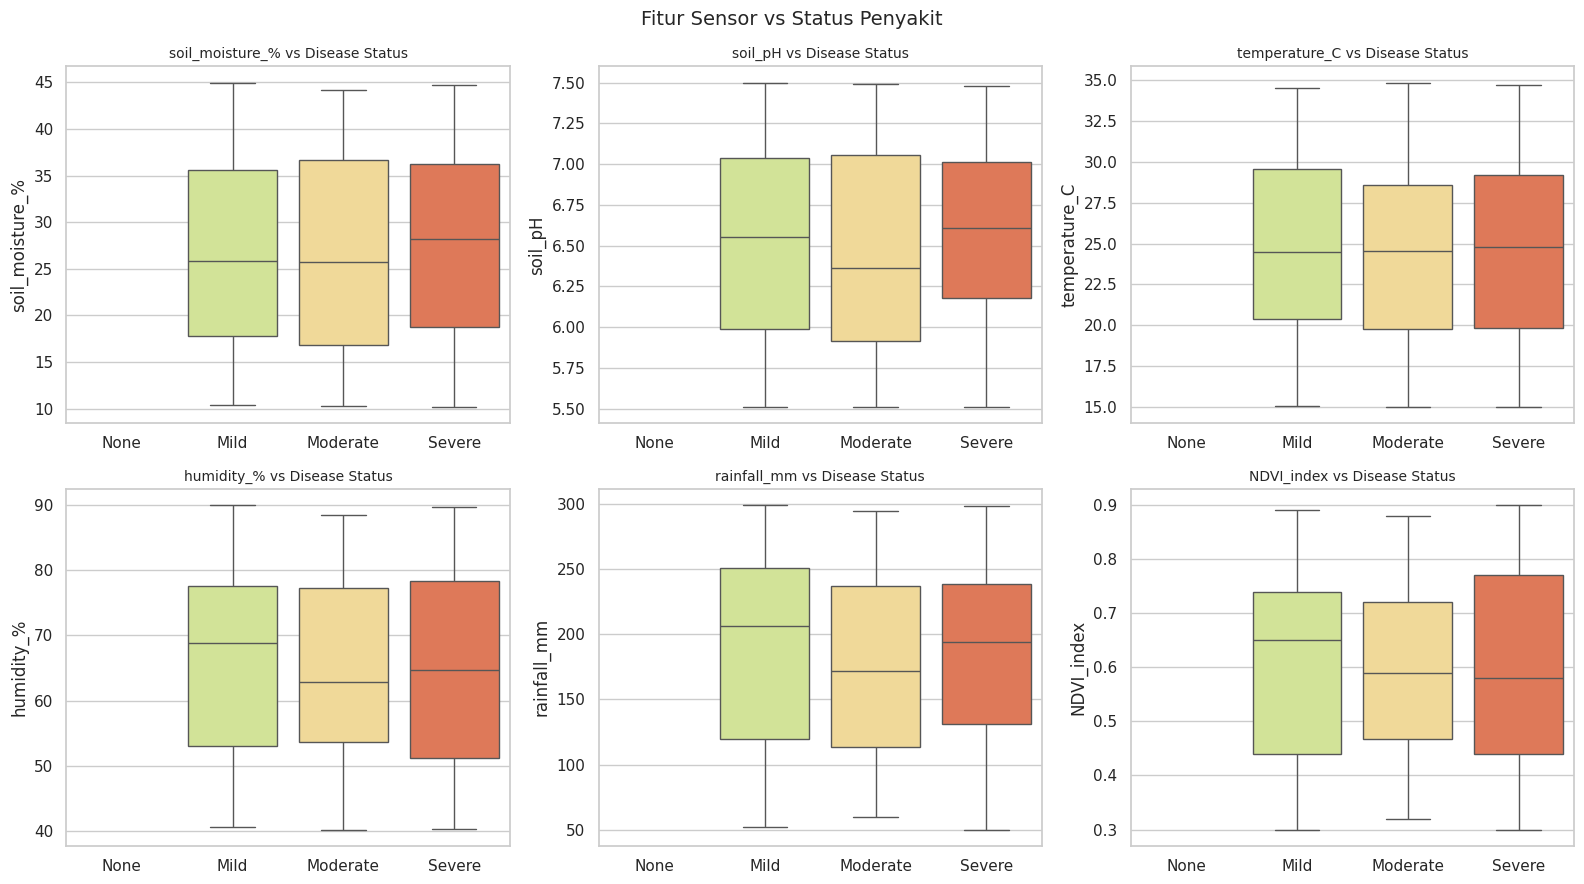

In [9]:
# ── 2.3 Boxplot fitur sensor per label penyakit
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat2 = axes.flatten()
order = ['None', 'Mild', 'Moderate', 'Severe']

for i, col in enumerate(['soil_moisture_%', 'soil_pH', 'temperature_C',
                          'humidity_%', 'rainfall_mm', 'NDVI_index']):
    sns.boxplot(data=df, x='crop_disease_status', y=col,
                order=order, palette='RdYlGn_r', ax=axes_flat2[i])
    axes_flat2[i].set_title(f'{col} vs Disease Status', fontsize=10)
    axes_flat2[i].set_xlabel('')

plt.suptitle('Fitur Sensor vs Status Penyakit', fontsize=14)
plt.tight_layout()
plt.show()

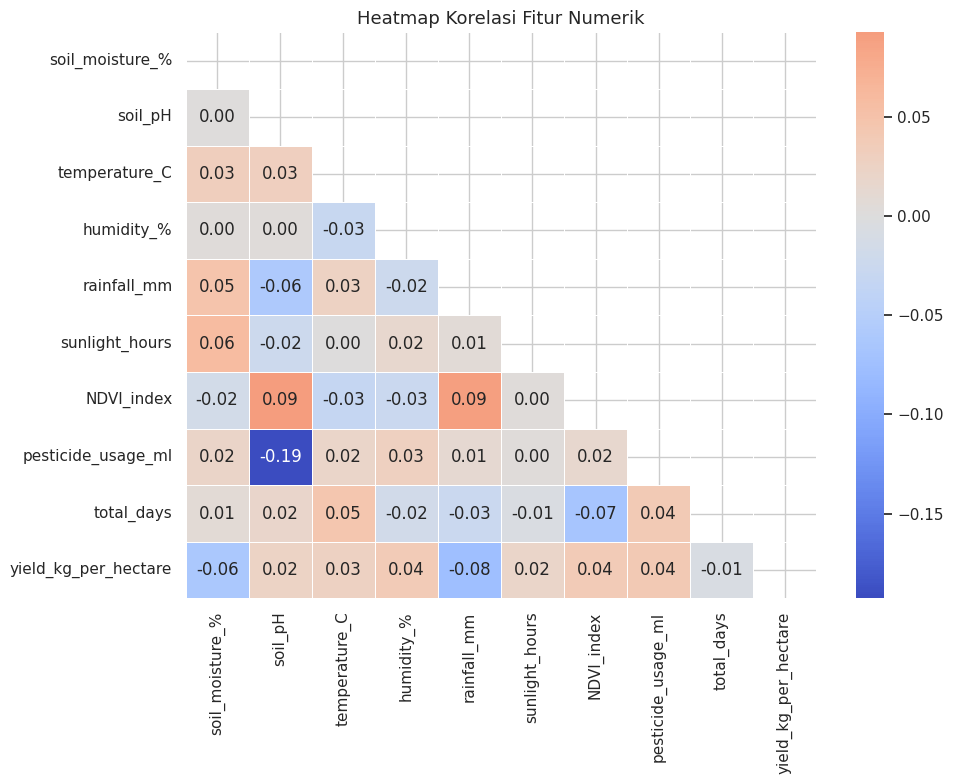

In [10]:
# ── 2.4 Heatmap korelasi fitur numerik
numeric_df: pd.DataFrame = df[sensor_cols + ['pesticide_usage_ml', 'total_days',
                               'yield_kg_per_hectare']].dropna()
# FIX: pastikan numeric_df adalah DataFrame agar .corr() tersedia
assert isinstance(numeric_df, pd.DataFrame)
corr: pd.DataFrame = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr.values, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=13)
plt.tight_layout()
plt.show()

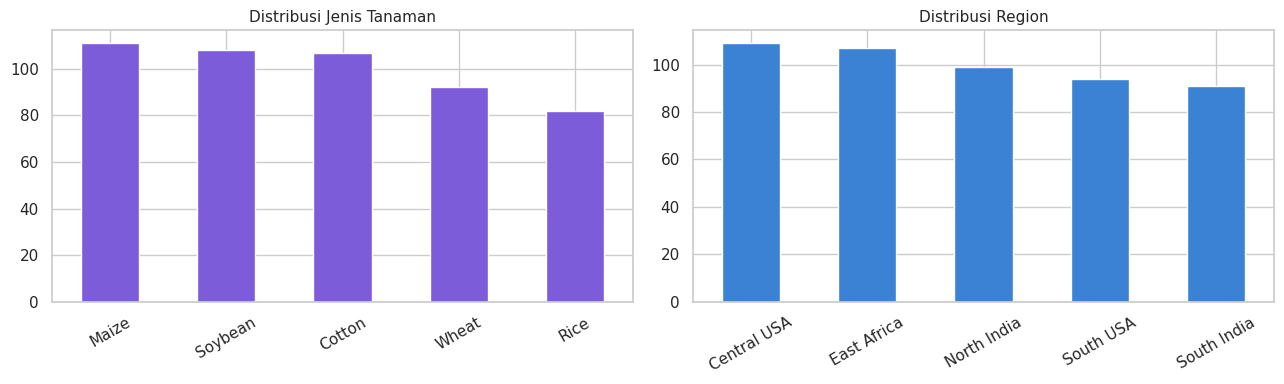

In [11]:
# ── 2.5 Distribusi crop_type dan region
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['crop_type'].value_counts().plot(kind='bar', ax=axes[0], color='#7c5cd8', edgecolor='white')
axes[0].set_title('Distribusi Jenis Tanaman', fontsize=11)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

df['region'].value_counts().plot(kind='bar', ax=axes[1], color='#3b82d4', edgecolor='white')
axes[1].set_title('Distribusi Region', fontsize=11)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 3. Data Cleaning

In [12]:
# ── 3.1 Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print('Missing Values per Kolom:')
has_missing = missing_report[missing_report['missing_count'] > 0]
print(has_missing.to_string() if not has_missing.empty else '✅ Tidak ada missing values')

Missing Values per Kolom:
                     missing_count  missing_%
irrigation_type                150       30.0
crop_disease_status            130       26.0


In [13]:
# ── 3.2 Isi missing values (median untuk numerik, modus untuk kategoris)
# FIX: gunakan df[col] = df[col].fillna(val) — hindari inplace karena type issue
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        median_val: float = float(df[col].median())
        df[col] = df[col].fillna(median_val)
        print(f'  [NUM] {col}: diisi median = {median_val:.2f}')

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        mode_val: str = str(df[col].mode().iloc[0])
        df[col] = df[col].fillna(mode_val)
        print(f'  [CAT] {col}: diisi modus = {mode_val}')

print(f'\n✅ Total missing setelah cleaning: {df.isnull().sum().sum()}')

  [CAT] irrigation_type: diisi modus = Sprinkler
  [CAT] crop_disease_status: diisi modus = Severe

✅ Total missing setelah cleaning: 0


In [14]:
# ── 3.3 Hapus duplikat
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f'Duplikat dihapus: {before - after} baris | Sisa: {after:,} baris')

Duplikat dihapus: 0 baris | Sisa: 500 baris


In [15]:
# ── 3.4 Deteksi & tangani outlier IQR pada fitur sensor utama
def remove_outliers_iqr(dataframe: pd.DataFrame, columns: list[str], factor: float = 3.0) -> pd.DataFrame:
    """Hapus outlier ekstrem menggunakan IQR × factor."""
    df_clean = dataframe.copy()
    total_removed = 0
    for col in columns:
        q1: float = float(df_clean[col].quantile(0.25))
        q3: float = float(df_clean[col].quantile(0.75))
        iqr: float = q3 - q1
        lower: float = q1 - factor * iqr
        upper: float = q3 + factor * iqr
        mask = (df_clean[col] >= lower) & (df_clean[col] <= upper)
        removed = int((~mask).sum())
        if removed > 0:
            print(f'  {col}: {removed} outlier dihapus (batas {lower:.2f}–{upper:.2f})')
            total_removed += removed
        df_clean = df_clean[mask]
    print(f'\nTotal outlier dihapus: {total_removed} | Sisa: {len(df_clean):,} baris')
    return df_clean

outlier_cols: list[str] = ['soil_moisture_%', 'soil_pH', 'temperature_C', 'humidity_%',
                            'rainfall_mm', 'sunlight_hours', 'NDVI_index']
df = remove_outliers_iqr(df, outlier_cols)


Total outlier dihapus: 0 | Sisa: 500 baris


---
## 4. Feature Engineering

In [16]:
# ── 4.1 Parse tanggal dan hitung days_since_sowing
df['sowing_date']  = pd.to_datetime(df['sowing_date'],  errors='coerce')
df['harvest_date'] = pd.to_datetime(df['harvest_date'], errors='coerce')
df['timestamp']    = pd.to_datetime(df['timestamp'],    errors='coerce')

# FIX: hasil pengurangan Timedelta Series — akses .dt.days langsung di Series
delta: pd.Series = df['timestamp'] - df['sowing_date']  # type: ignore[operator]
df['days_since_sowing'] = delta.dt.days.clip(lower=0)
print('✅ Fitur days_since_sowing dibuat')

✅ Fitur days_since_sowing dibuat


In [17]:
# ── 4.2 Fitur turunan dari sensor ArgoMind

# Water Stress Index: rendah moisture + tinggi temperature = stres air
df['water_stress_index'] = (
    (100 - df['soil_moisture_%']) * df['temperature_C']
) / 100

# Disease Pressure Score: kombinasi faktor yang memicu penyakit
df['disease_pressure_score'] = (
    df['humidity_%'] * 0.4 +
    df['rainfall_mm'] * 0.3 +
    (df['temperature_C'] / 40) * 100 * 0.3
).round(2)

# FIX: gunakan np.abs() agar tidak bergantung pada .abs() milik Series
df['ph_deviation'] = np.round(np.abs(df['soil_pH'].values - 6.5), 3)

# FIX: gunakan np.where agar tidak bergantung pada .replace() milik Series
total_days_safe = np.where(df['total_days'].values == 0, np.nan, df['total_days'].values)
df['yield_per_day'] = np.round(df['yield_kg_per_hectare'].values / total_days_safe, 2)

print('✅ Fitur baru dibuat:', ['water_stress_index', 'disease_pressure_score',
                                 'ph_deviation', 'yield_per_day'])

✅ Fitur baru dibuat: ['water_stress_index', 'disease_pressure_score', 'ph_deviation', 'yield_per_day']


In [18]:
# ── 4.3 Encode fitur kategoris

# One-Hot Encoding untuk kolom dengan kardinalitas rendah
df = pd.get_dummies(df, columns=['irrigation_type', 'fertilizer_type'], drop_first=False)

# Label Encoding untuk crop_type dan region
le_crop   = LabelEncoder()
le_region = LabelEncoder()
df['crop_type_enc'] = le_crop.fit_transform(df['crop_type'])
df['region_enc']    = le_region.fit_transform(df['region'])

# FIX: konversi ke list Python untuk menghindari type mismatch pada dict(zip(...))
crop_classes: list[str]   = le_crop.classes_.tolist()
crop_encoded: list[int]   = le_crop.transform(le_crop.classes_).tolist()
region_classes: list[str] = le_region.classes_.tolist()
region_encoded: list[int] = le_region.transform(le_region.classes_).tolist()

print('crop_type mapping :', dict(zip(crop_classes, crop_encoded)))
print('region mapping    :', dict(zip(region_classes, region_encoded)))

crop_type mapping : {'Cotton': 0, 'Maize': 1, 'Rice': 2, 'Soybean': 3, 'Wheat': 4}
region mapping    : {'Central USA': 0, 'East Africa': 1, 'North India': 2, 'South India': 3, 'South USA': 4}


In [19]:
# ── 4.4 Encode label target
# FIX: gunakan fit_transform agar .classes_ ter-set otomatis dengan urutan yang benar
label_order: list[str] = ['None', 'Mild', 'Moderate', 'Severe']
le_label = LabelEncoder()
le_label.fit(label_order)  # fit dulu agar urutan sesuai

safe_labels: pd.Series = df['crop_disease_status'].map(
    lambda x: x if x in label_order else 'None'
)
df['label'] = le_label.transform(safe_labels)

# FIX: konversi classes_ ke list Python
label_classes: list[str] = le_label.classes_.tolist()
print('Label mapping :', dict(zip(label_classes, range(len(label_classes)))))
print(df['label'].value_counts())

Label mapping : {'Mild': 0, 'Moderate': 1, 'None': 2, 'Severe': 3}
label
3    263
0    125
1    112
Name: count, dtype: int64


---
## 5. Feature Selection

In [20]:
# Kolom fitur yang akan digunakan oleh model ArgoMind
CORE_SENSOR_FEATURES: list[str] = [
    'soil_moisture_%',
    'soil_pH',
    'temperature_C',
    'humidity_%',
    'rainfall_mm',
    'sunlight_hours',
    'NDVI_index',
]

ENGINEERED_FEATURES: list[str] = [
    'water_stress_index',
    'disease_pressure_score',
    'ph_deviation',
    'yield_per_day',
    'days_since_sowing',
    'pesticide_usage_ml',
    'crop_type_enc',
    'region_enc',
]

# One-hot kolom irrigation & fertilizer yang terbentuk dari get_dummies
OHE_FEATURES: list[str] = [c for c in df.columns
                            if c.startswith('irrigation_type_') or c.startswith('fertilizer_type_')]

ALL_FEATURES: list[str] = CORE_SENSOR_FEATURES + ENGINEERED_FEATURES + OHE_FEATURES

print(f'Total fitur yang digunakan: {len(ALL_FEATURES)}')
print(ALL_FEATURES)

Total fitur yang digunakan: 21
['soil_moisture_%', 'soil_pH', 'temperature_C', 'humidity_%', 'rainfall_mm', 'sunlight_hours', 'NDVI_index', 'water_stress_index', 'disease_pressure_score', 'ph_deviation', 'yield_per_day', 'days_since_sowing', 'pesticide_usage_ml', 'crop_type_enc', 'region_enc', 'irrigation_type_Drip', 'irrigation_type_Manual', 'irrigation_type_Sprinkler', 'fertilizer_type_Inorganic', 'fertilizer_type_Mixed', 'fertilizer_type_Organic']


In [21]:
# Subset dataframe
df_model: pd.DataFrame = df[ALL_FEATURES + ['label', 'crop_disease_status', 'farm_id']].copy()
# FIX: dropna tanpa inplace agar type checker mengenali return type sebagai DataFrame
df_model = df_model.dropna(subset=ALL_FEATURES + ['label'])
print(f'Dataset siap model: {df_model.shape[0]:,} baris × {len(ALL_FEATURES)} fitur')
df_model.head(3)

Dataset siap model: 500 baris × 21 fitur


,soil_moisture_%,soil_pH,temperature_C,humidity_%,rainfall_mm,sunlight_hours,NDVI_index,water_stress_index,disease_pressure_score,ph_deviation,...,region_enc,irrigation_type_Drip,irrigation_type_Manual,irrigation_type_Sprinkler,fertilizer_type_Inorganic,fertilizer_type_Mixed,fertilizer_type_Organic,label,crop_disease_status,farm_id
0,35.95,5.99,17.79,77.03,75.62,7.27,0.63,11.394495,66.84,0.51,...,2,False,False,True,False,False,True,0,Mild,FARM0001
1,19.74,7.24,30.18,61.13,89.91,5.67,0.58,24.222468,74.06,0.74,...,4,False,False,True,True,False,False,3,Severe,FARM0002
2,29.32,7.16,27.37,68.87,265.43,8.23,0.80,19.345116,127.70,0.66,...,4,True,False,False,False,True,False,0,Mild,FARM0003


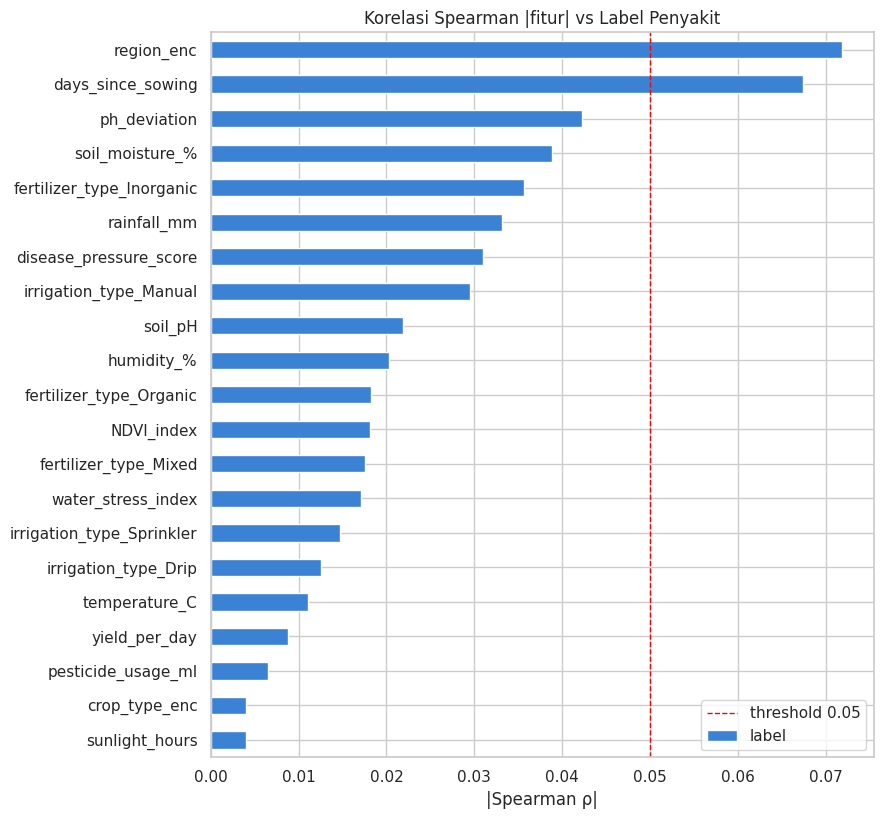

In [22]:
# ── Feature importance awal (korelasi Spearman dengan label)
# FIX: pastikan input adalah DataFrame sebelum memanggil .corr()
corr_df: pd.DataFrame = df_model[ALL_FEATURES + ['label']]
assert isinstance(corr_df, pd.DataFrame)
spearman_full: pd.DataFrame = corr_df.corr(method='spearman')  # type: ignore[arg-type]
spearman_corr: pd.Series = spearman_full['label'].drop('label')
# FIX: gunakan .abs() di Series, lalu .sort_values() dengan ascending keyword
spearman_corr = spearman_corr.abs()
spearman_corr = spearman_corr.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, len(spearman_corr) * 0.35 + 1))
spearman_corr.plot(kind='barh', ax=ax, color='#3b82d4', edgecolor='white')
ax.axvline(0.05, color='red', linestyle='--', linewidth=1, label='threshold 0.05')
ax.set_title('Korelasi Spearman |fitur| vs Label Penyakit', fontsize=12)
ax.set_xlabel('|Spearman ρ|')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Normalisasi (StandardScaler)

In [23]:
X: np.ndarray = df_model[ALL_FEATURES].values
y: np.ndarray = df_model['label'].values

scaler = StandardScaler()
X_scaled: np.ndarray = scaler.fit_transform(X)

print('Mean (5 fitur pertama)  :', scaler.mean_[:5].round(4))
print('Std  (5 fitur pertama)  :', scaler.scale_[:5].round(4))
print(f'\nShape X_scaled : {X_scaled.shape}')
print(f'Shape y        : {y.shape}')

Mean (5 fitur pertama)  : [ 26.7501   6.524   24.6757  65.1945 181.6857]
Std  (5 fitur pertama)  : [10.1399  0.585   5.3435 14.6282 72.2208]

Shape X_scaled : (500, 21)
Shape y        : (500,)


---
## 7. Train / Test Split

In [24]:
X_train: np.ndarray
X_test:  np.ndarray
y_train: np.ndarray
y_test:  np.ndarray

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # stratified: proporsi label tetap seimbang
)

print(f'Train  : {X_train.shape[0]:,} sampel')
print(f'Test   : {X_test.shape[0]:,} sampel')
print()
print('Distribusi label — Train:')
unique_vals, train_counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique_vals.tolist(), train_counts.tolist()):
    print(f'  {label_order[int(u)]:10s}: {c}')

print('\nDistribusi label — Test:')
unique_vals, test_counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique_vals.tolist(), test_counts.tolist()):
    print(f'  {label_order[int(u)]:10s}: {c}')

Train  : 400 sampel
Test   : 100 sampel

Distribusi label — Train:
  None      : 100
  Mild      : 90
  Severe    : 210

Distribusi label — Test:
  None      : 25
  Mild      : 22
  Severe    : 53


---
## 8. Export Dataset


In [ ]:

df_clean_export: pd.DataFrame = df_model.drop(columns=['label']).rename(
    columns={'crop_disease_status': 'label'}
)  # type: ignore[assignment]
df_clean_export.to_csv(CLEAN_CSV, index=False)
print(f'✅ Dataset bersih disimpan: {CLEAN_CSV}  ({len(df_clean_export):,} baris)')

✅ Dataset bersih disimpan: sensor_dataset_clean.csv  (500 baris)
